<a href="https://colab.research.google.com/github/Lydia-fadele/AfroDiabDB/blob/main/notebooks/AfroDiabDB_Master_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AfroDiabDB — Master Pipeline Notebook
Curated chemoinformatics database of antidiabetic phytochemicals from African medicinal plants.

This notebook consolidates: data loading, structure/descriptor correction, validation, drug-likeness and QED calculation, Chapter 3 figures/tables, CSV/SDF export, and GitHub sync.

## 1. Setup — Mount Drive, Install Packages

In [1]:
from google.colab import drive
drive.mount('/content/drive')

!pip install rdkit -q
!pip install pubchempy -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, re, time

from rdkit import Chem, RDLogger
from rdkit.Chem import Descriptors, Crippen, rdMolDescriptors, QED
RDLogger.DisableLog('rdApp.*')

import pubchempy as pcp
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 150

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.4/37.4 MB 22.0 MB/s eta 0:00:00


## 2. Load Workbook

In [2]:
filename = '/content/drive/MyDrive/AfroDiabDB_v1.4.xlsx'  # adjust path if it's in a subfolder

nat = pd.read_excel(filename, sheet_name='Natural_Products')
drugs = pd.read_excel(filename, sheet_name='Clinically_Approved_Drugs')

print("Natural_Products:", nat.shape)
print("Clinically_Approved_Drugs:", drugs.shape)

Natural_Products: (251, 37)
Clinically_Approved_Drugs: (19, 22)


## 3. Structure & Descriptor Recomputation Functions
Recomputes InChIKey and all descriptors directly from Canonical_SMILES using RDKit.

In [3]:
def recompute_row(smiles):
    mol = Chem.MolFromSmiles(str(smiles))
    if mol is None:
        return None
    inchi = Chem.MolToInchi(mol)
    inchikey = Chem.InchiToInchiKey(inchi)
    return {
        'InChIKey': inchikey,
        'Molecular_Formula': rdMolDescriptors.CalcMolFormula(mol),
        'Molecular_Weight': round(Descriptors.MolWt(mol), 3),
        'LogP': round(Crippen.MolLogP(mol), 4),
        'HBD': rdMolDescriptors.CalcNumHBD(mol),
        'HBA': rdMolDescriptors.CalcNumHBA(mol),
        'TPSA': round(rdMolDescriptors.CalcTPSA(mol), 2),
        'Rotatable_Bonds': rdMolDescriptors.CalcNumRotatableBonds(mol),
        'Fraction_CSP3': round(rdMolDescriptors.CalcFractionCSP3(mol), 6),
        'Ring_Count': rdMolDescriptors.CalcNumRings(mol),
        'Aromatic_Ring_Count': rdMolDescriptors.CalcNumAromaticRings(mol),
        'Heavy_Atom_Count': mol.GetNumHeavyAtoms(),
        'Molar_Refractivity': round(Crippen.MolMR(mol), 4),
        'QED_Score': round(QED.qed(mol), 6),
    }

def lipinski(row):
    v = sum([row['Molecular_Weight']>500, row['LogP']>5, row['HBD']>5, row['HBA']>10])
    return v, ('Pass' if v<=1 else 'Fail')

def veber(row):
    ok = row['Rotatable_Bonds']<=10 and row['TPSA']<=140
    return 'Pass' if ok else 'Fail'

def ghose(row):
    v = sum([
        not (160<=row['Molecular_Weight']<=480),
        not (-0.4<=row['LogP']<=5.6),
        not (40<=row['Molar_Refractivity']<=130),
        not (20<=row['Heavy_Atom_Count']<=70),
    ])
    return v, ('Pass' if v==0 else 'Fail')

def correct_sheet(df, name):
    df = df.copy()
    changelog = []
    for idx, row in df.iterrows():
        result = recompute_row(row['Canonical_SMILES'])
        if result is None:
            changelog.append({'Sheet':name,'Row':idx,'Compound':row.get('Compound_Name'),
                               'Issue':'INVALID SMILES — needs manual fix'})
            continue
        for col, new_val in result.items():
            if col in df.columns:
                old_val = row[col]
                if str(old_val) != str(new_val):
                    changelog.append({'Sheet':name,'Row':idx,'Compound':row.get('Compound_Name'),
                                       'Field':col,'Old':old_val,'New':new_val})
                df.at[idx, col] = new_val
    lip = df.apply(lipinski, axis=1)
    df['Lipinski_Violations'] = [x[0] for x in lip]
    df['Lipinski_Status']     = [x[1] for x in lip]
    df['Veber_Status']        = df.apply(veber, axis=1)
    gho = df.apply(ghose, axis=1)
    df['Ghose_Violations'] = [x[0] for x in gho]
    df['Ghose_Status']     = [x[1] for x in gho]
    return df, changelog

## 4. Apply Corrections

In [4]:
drugs_fixed, log1 = correct_sheet(drugs, 'Clinically_Approved_Drugs')
nat_fixed, log2   = correct_sheet(nat, 'Natural_Products')

change_log = pd.DataFrame(log1 + log2)
print(f"Total corrections logged: {len(change_log)}")
print("drugs_fixed shape:", drugs_fixed.shape)
print("nat_fixed shape:", nat_fixed.shape)

Total corrections logged: 0
drugs_fixed shape: (19, 22)
nat_fixed shape: (251, 37)


## 5. Pull Verified Structures from PubChem (for benchmark drugs)

In [5]:
def get_correct_smiles(name):
    try:
        results = pcp.get_compounds(name, 'name')
        if results:
            return results[0].isomeric_smiles
    except Exception as e:
        print(f"  Failed for {name}: {e}")
    return None

for idx, row in drugs_fixed.iterrows():
    correct_smi = get_correct_smiles(row['Compound_Name'])
    if correct_smi:
        drugs_fixed.at[idx, 'Canonical_SMILES'] = correct_smi
    time.sleep(0.5)

drugs_fixed, log_pubchem = correct_sheet(drugs_fixed, 'Clinically_Approved_Drugs')
print(f"{len(log_pubchem)} fields corrected after pulling verified structures")

/tmp/ipykernel_452/1145030627.py:5: PubChemPyDeprecationWarning: isomeric_smiles is deprecated: Use smiles instead
  return results[0].isomeric_smiles


0 fields corrected after pulling verified structures


## 6. Regulatory Approval Labeling

In [6]:
non_fda = ['Gliclazide', 'Voglibose']
drugs_fixed['Regulatory_Approval'] = drugs_fixed['Compound_Name'].apply(
    lambda x: 'EMA/CDSCO/PMDA (non-US)' if x in non_fda else 'FDA-approved'
)
print(drugs_fixed[['Compound_Name','Regulatory_Approval']])

    Compound_Name      Regulatory_Approval
0       Metformin             FDA-approved
1     Sitagliptin             FDA-approved
2     Saxagliptin             FDA-approved
3     Linagliptin             FDA-approved
4      Alogliptin             FDA-approved
5   Empagliflozin             FDA-approved
6   Dapagliflozin             FDA-approved
7   Canagliflozin             FDA-approved
8    Pioglitazone             FDA-approved
9   Rosiglitazone             FDA-approved
10  Glibenclamide             FDA-approved
11    Glimepiride             FDA-approved
12      Glipizide             FDA-approved
13     Gliclazide  EMA/CDSCO/PMDA (non-US)
14       Acarbose             FDA-approved
15       Miglitol             FDA-approved
16      Voglibose  EMA/CDSCO/PMDA (non-US)
17    Repaglinide             FDA-approved
18    Nateglinide             FDA-approved


## 7. Structural Consistency Check
Flags any compound name with more than one distinct SMILES across rows.

In [7]:
def flag_inconsistent_names(df):
    df = df.reset_index(drop=True)
    df['QC_Flag'] = ''
    for name, grp in df.groupby('Compound_Name'):
        if grp['Canonical_SMILES'].nunique() > 1:
            df.loc[grp.index, 'QC_Flag'] = 'REVIEW: same Compound_Name, different SMILES across rows'
    return df

nat_fixed = flag_inconsistent_names(nat_fixed)
print(f"Flagged rows: {(nat_fixed['QC_Flag']!='').sum()}")
nat_fixed[nat_fixed['QC_Flag']!=''][['Compound_ID','Compound_Name','Plant_Name','Canonical_SMILES','Molecular_Weight']]

Flagged rows: 23


,Compound_ID,Compound_Name,Plant_Name,Canonical_SMILES,Molecular_Weight
3,AFRO-0004,Caffeic Acid,Vernonia amygdalina,O=C(O)C=Cc1ccc(O)c(O)c1,180.159
8,AFRO-0009,Ellagic Acid,Moringa oleifera,C1=C2C3=C(C(=C1O)O)OC(=O)C4=CC(=C(C(=C43)OC2=O...,302.194
11,AFRO-0012,Rutin,Moringa oleifera,C[C@@H]1O[C@@H](OC[C@H]2O[C@@H](Oc3c(-c4ccc(O)...,610.521
13,AFRO-0014,Chlorogenic Acid,Moringa oleifera,O=C(/C=C/c1ccc(O)c(O)c1)O[C@@H]1C[C@](O)(C(=O)...,354.311
29,AFRO-0030,Beta-Sitosterol,Moringa oleifera,CC[C@H](CC[C@@H](C)[C@H]1CC[C@H]2[C@@H]3CC=C4C...,414.718
30,AFRO-0031,Caffeic Acid,Moringa oleifera,O=C(O)/C=C/c1ccc(O)c(O)c1,180.159
35,AFRO-0036,p-Coumaric Acid,Moringa oleifera,O=C(O)/C=C/c1ccc(O)cc1,164.160
47,AFRO-0048,Caffeic Acid,Anacardium occidentale,O=C(O)/C=C/c1ccc(O)c(O)c1,180.159
63,AFRO-0064,Beta-Sitosterol,Coccinia indica,CCC(CCC(C)C1CCC2C3CC=C4CC(O)CCC4(C)C3CCC12C)C(C)C,414.718
98,AFRO-0099,Chlorogenic Acid,Vernonia amygdalina,O=C(C=Cc1ccc(O)c(O)c1)OC1CC(O)(C(=O)O)CC(O)C1O,354.311


## 8. Validation — Structural Validity, PubChem Cross-Check, Reference Check

In [8]:
# Tier 1: structural validity
invalid = [row['Compound_ID'] for idx, row in nat_fixed.iterrows()
           if Chem.MolFromSmiles(str(row['Canonical_SMILES'])) is None]
print(f"Structurally invalid SMILES: {len(invalid)}")

# Tier 2: PubChem CID cross-check
cid_mismatches = []
for idx, row in nat_fixed.iterrows():
    try:
        c = pcp.Compound.from_cid(int(row['PubChem_CID']))
        if c.molecular_formula != row['Molecular_Formula']:
            cid_mismatches.append(row['Compound_ID'])
    except Exception:
        cid_mismatches.append(row['Compound_ID'])
    time.sleep(0.3)
print(f"CID/formula mismatches: {len(cid_mismatches)}")

Structurally invalid SMILES: 0
CID/formula mismatches: 31


In [9]:
# Tier 3: reference resolution check (handles both DOI and URL entries)
import requests

def check_reference(val):
    val = str(val).strip()
    if val.startswith('10.'):
        url = f'https://doi.org/{val}'
    elif val.startswith('http'):
        url = val
    else:
        return False, 'Malformed — not a DOI or URL'
    try:
        r = requests.get(url, timeout=15, allow_redirects=True, headers={'User-Agent':'Mozilla/5.0'})
        return r.status_code < 400, f'HTTP {r.status_code}'
    except Exception as e:
        return False, str(e)

# NOTE: this loop can take a while for 251 rows — run only when needed
# broken = []
# for idx, row in nat_fixed.iterrows():
#     ok, note = check_reference(row['Source_DOI_or_URL'])
#     if not ok:
#         broken.append({'Compound_ID': row['Compound_ID'], 'Reference': row['Source_DOI_or_URL'], 'Issue': note})
#     time.sleep(1)
# broken_df = pd.DataFrame(broken)
# print(f"Broken references: {len(broken_df)} / {len(nat_fixed)}")

## 9. Save Corrected Workbook

In [10]:
nat_final = nat_fixed.drop(columns=['QC_Flag']) if 'QC_Flag' in nat_fixed.columns else nat_fixed.copy()

out_name = '/content/drive/MyDrive/AfroDiabDB_v1.4.xlsx'
with pd.ExcelWriter(out_name, engine='openpyxl') as writer:
    drugs_fixed.to_excel(writer, sheet_name='Clinically_Approved_Drugs', index=False)
    nat_final.to_excel(writer, sheet_name='Natural_Products', index=False)

print(f"Saved: {out_name}")

Saved: /content/drive/MyDrive/AfroDiabDB_v1.4.xlsx


## 10. Export CSV and SDF

In [11]:
export_dir = '/content/drive/MyDrive/AfroDiabDB_Exports'
os.makedirs(export_dir, exist_ok=True)

nat_final.to_csv(f'{export_dir}/AfroDiabDB_Natural_Products.csv', index=False)
drugs_fixed.to_csv(f'{export_dir}/AfroDiabDB_Clinically_Approved_Drugs.csv', index=False)

def build_sdf(df, out_path, id_col, extra_props):
    writer = Chem.SDWriter(out_path)
    failed = []
    for idx, row in df.iterrows():
        mol = Chem.MolFromSmiles(str(row['Canonical_SMILES']))
        if mol is None:
            failed.append(row.get(id_col, idx))
            continue
        mol.SetProp('_Name', str(row.get(id_col, idx)))
        for prop in extra_props:
            if prop in df.columns and pd.notna(row[prop]):
                mol.SetProp(prop, str(row[prop]))
        writer.write(mol)
    writer.close()
    return failed

nat_props = ['Compound_Name','Plant_Name','Plant_Family','Compound_Superclass',
             'PubChem_CID','InChIKey','Molecular_Formula','Molecular_Weight','LogP','QED_Score','Lipinski_Status']
build_sdf(nat_final, f'{export_dir}/AfroDiabDB_Natural_Products.sdf', 'Compound_ID', nat_props)

drugs_props = ['Compound_Name','InChIKey','Molecular_Weight','LogP','QED_Score','Lipinski_Status','Regulatory_Approval']
build_sdf(drugs_fixed, f'{export_dir}/AfroDiabDB_Clinically_Approved_Drugs.sdf', 'Compound_Name', drugs_props)

print("CSV and SDF export complete:")
for f in sorted(os.listdir(export_dir)):
    print(" ", f)

CSV and SDF export complete:
  AfroDiabDB_Clinically_Approved_Drugs.csv
  AfroDiabDB_Clinically_Approved_Drugs.sdf
  AfroDiabDB_Natural_Products.csv
  AfroDiabDB_Natural_Products.sdf


## 11. Chapter 3 — Tables and Figures
Outputs saved to `AfroDiabDB_Chapter3_Outputs/figures` and `/tables`.

In [12]:
output_dir = '/content/drive/MyDrive/AfroDiabDB_Chapter3_Outputs'
os.makedirs(f'{output_dir}/figures', exist_ok=True)
os.makedirs(f'{output_dir}/tables', exist_ok=True)

nat_unique = nat_final.drop_duplicates(subset='Canonical_SMILES')
descriptors = ['Molecular_Weight','LogP','HBD','HBA','TPSA','Rotatable_Bonds',
               'Molar_Refractivity','Fraction_CSP3','Ring_Count','Aromatic_Ring_Count','Heavy_Atom_Count']

In [13]:
# Table 3.1 — Database summary
table_3_1 = pd.DataFrame({
    'Metric': ['Occurrence records','Unique compound entities','Unique molecular structures',
               'African plant species','Botanical families','Validated PubChem CIDs','Unique InChIKeys'],
    'Value': [len(nat_final), nat_final['Compound_Name'].nunique(), nat_final['Canonical_SMILES'].nunique(),
              nat_final['Plant_Name'].nunique(), nat_final['Plant_Family'].nunique(),
              nat_final['PubChem_CID'].notna().sum(), nat_final['InChIKey'].nunique()]
})
table_3_1.to_csv(f'{output_dir}/tables/Table_3_1_Database_Summary.csv', index=False)
print(table_3_1)

                        Metric  Value
0           Occurrence records    251
1     Unique compound entities    206
2  Unique molecular structures    201
3        African plant species     48
4           Botanical families     28
5       Validated PubChem CIDs    251
6             Unique InChIKeys    198


/tmp/ipykernel_452/432361252.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=family_counts, y='Plant_Family', x='Count', palette='viridis')


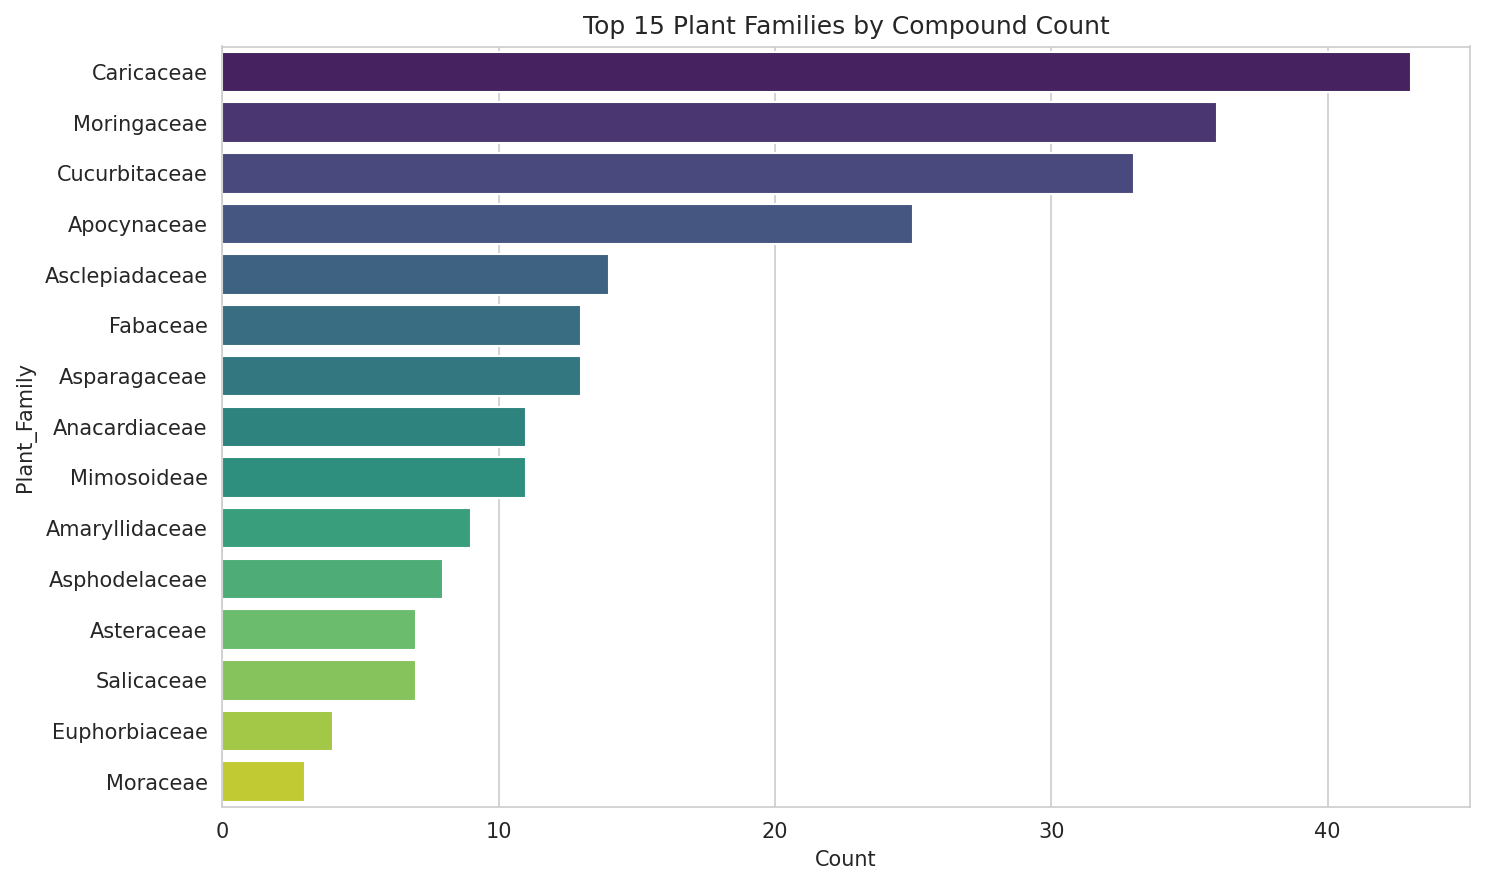

In [14]:
# Table 3.2 + Figure 3.1 — Top plant families
family_counts = nat_final['Plant_Family'].value_counts().head(15).reset_index()
family_counts.columns = ['Plant_Family','Count']
family_counts['Percentage'] = (family_counts['Count']/len(nat_final)*100).round(2)
family_counts.to_csv(f'{output_dir}/tables/Table_3_2_Top_Plant_Families.csv', index=False)

plt.figure(figsize=(10,6))
sns.barplot(data=family_counts, y='Plant_Family', x='Count', palette='viridis')
plt.title('Top 15 Plant Families by Compound Count')
plt.tight_layout()
plt.savefig(f'{output_dir}/figures/Figure_3_1_Top_Plant_Families.png', dpi=300)
plt.show()

/tmp/ipykernel_452/2695642053.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=part_counts.head(12), y='Plant_Part', x='Count', palette='crest')


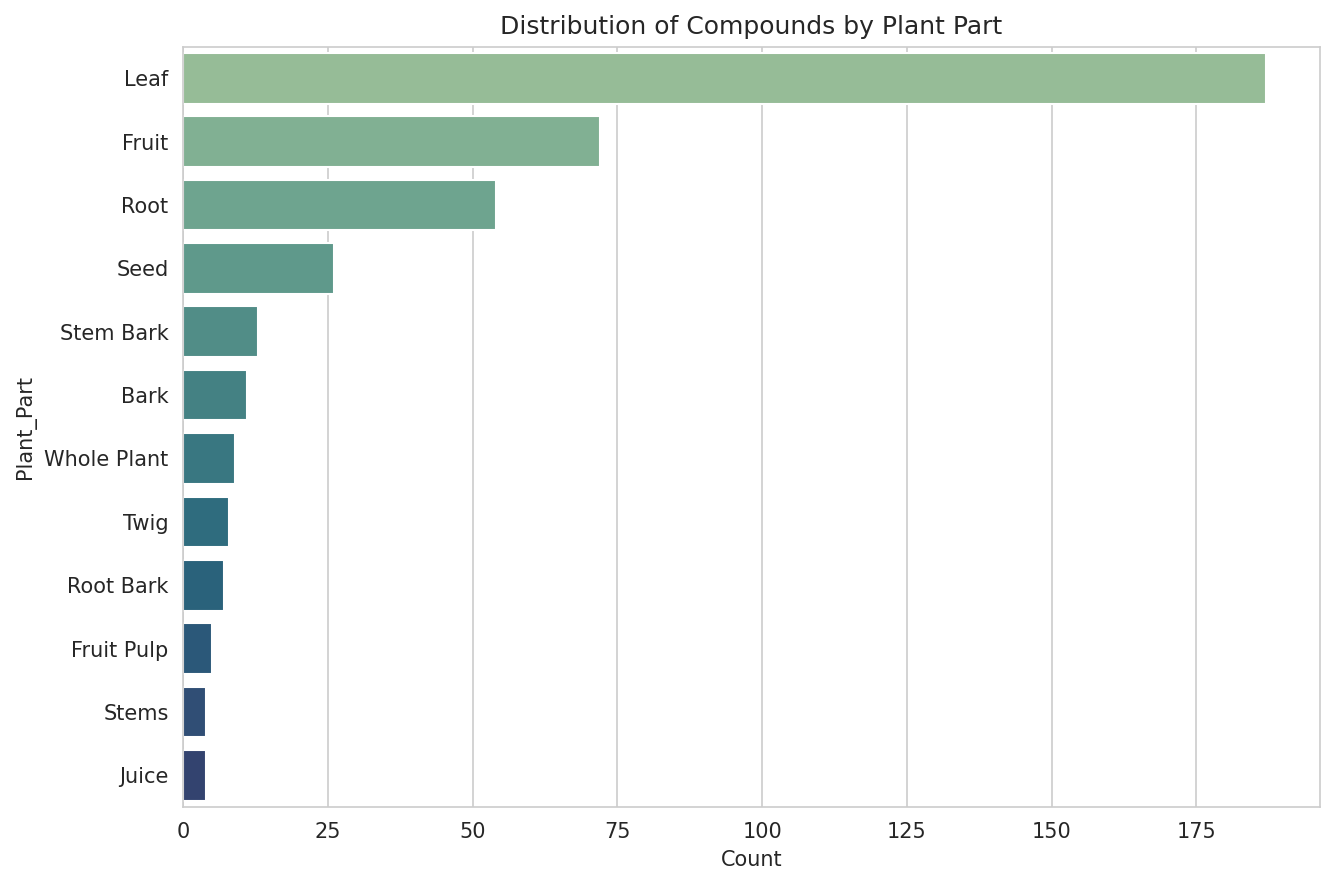

In [15]:
# Table 3.2b + Figure 3.1b — Plant part distribution (normalized)
def normalize_parts(raw):
    if pd.isna(raw): return []
    text = re.sub(r'[,/]', ';', str(raw))
    tokens = [t.strip().lower() for t in text.split(';') if t.strip()]
    mapping = {
        'leaf':'Leaf','leaves':'Leaf','leave':'Leaf','fresh leaf juice':'Leaf','leaf gel':'Leaf',
        'root':'Root','roots':'Root','seed':'Seed','seeds':'Seed','unripe fruit':'Fruit',
        'fruit':'Fruit','fruits':'Fruit','fruit pulp':'Fruit Pulp','bark':'Bark',
        'stem bark':'Stem Bark','root bark':'Root Bark','stem':'Stem','twig':'Twig','twigs':'Twig',
        'shoot':'Shoot','whole plant':'Whole Plant','aerial parts':'Aerial Parts',
        'rhizome':'Rhizome','rhizomes':'Rhizome','bulb':'Bulb','clove':'Clove',
        'kernel':'Kernel','kernels':'Kernel','peel':'Peel','flower':'Flower','resin':'Resin',
        'juice':'Juice','tuber':'Tuber'
    }
    return [mapping.get(t, t.title()) for t in tokens]

exploded_parts = nat_final['Plant_Part'].apply(normalize_parts).explode()
part_counts = exploded_parts.value_counts().reset_index()
part_counts.columns = ['Plant_Part','Count']
part_counts['Percentage'] = (part_counts['Count']/len(nat_final)*100).round(2)
part_counts.to_csv(f'{output_dir}/tables/Table_3_2b_Plant_Part_Distribution.csv', index=False)

plt.figure(figsize=(9,6))
sns.barplot(data=part_counts.head(12), y='Plant_Part', x='Count', palette='crest')
plt.title('Distribution of Compounds by Plant Part')
plt.tight_layout()
plt.savefig(f'{output_dir}/figures/Figure_3_1b_Plant_Part_Distribution.png', dpi=300)
plt.show()

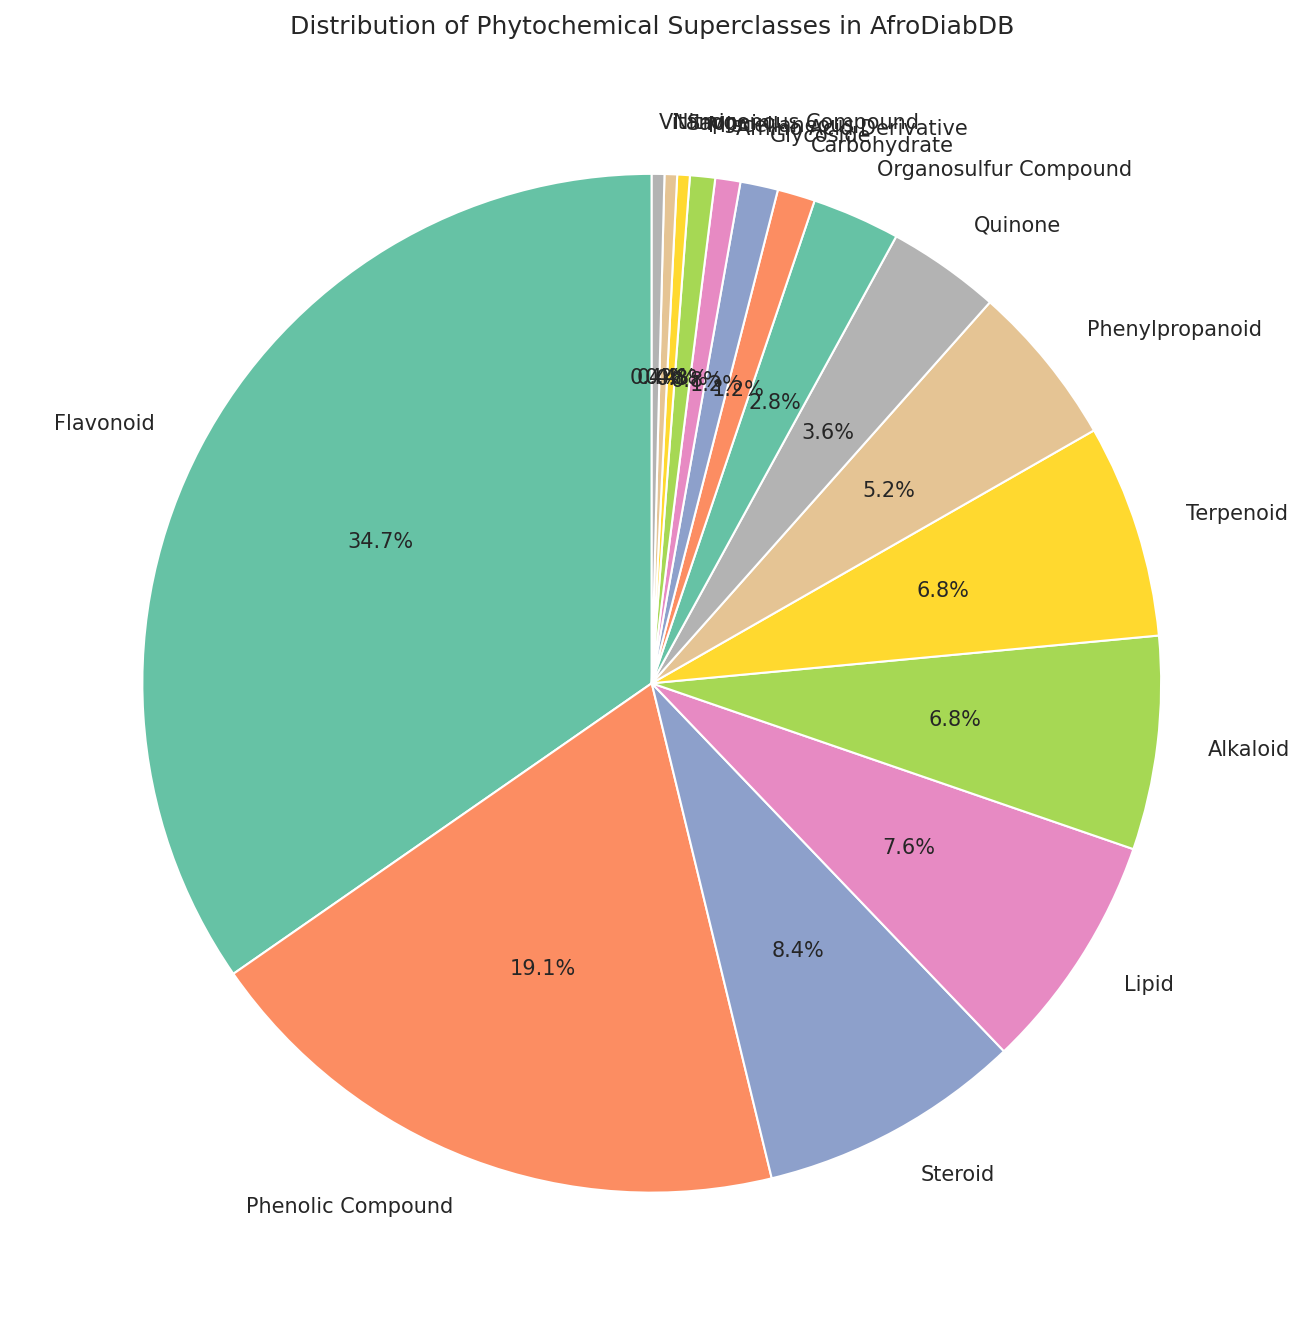

In [16]:
# Table 3.3 + Figure 3.2 — Superclass distribution
super_counts = nat_final['Compound_Superclass'].value_counts().reset_index()
super_counts.columns = ['Compound_Superclass','Count']
super_counts['Percentage'] = (super_counts['Count']/len(nat_final)*100).round(2)
super_counts.to_csv(f'{output_dir}/tables/Table_3_3_Superclass_Distribution.csv', index=False)

plt.figure(figsize=(9,9))
plt.pie(super_counts['Count'], labels=super_counts['Compound_Superclass'], autopct='%1.1f%%',
        startangle=90, colors=sns.color_palette('Set2', len(super_counts)))
plt.title('Distribution of Phytochemical Superclasses in AfroDiabDB')
plt.tight_layout()
plt.savefig(f'{output_dir}/figures/Figure_3_2_Superclass_Distribution.png', dpi=300)
plt.show()

In [17]:
# Tables 3.4 & 3.5 — Descriptive statistics
table_3_4 = nat_unique[descriptors].agg(['mean','std','median','min','max']).T.round(3)
table_3_4.to_csv(f'{output_dir}/tables/Table_3_4_AfroDiabDB_Descriptors.csv')

table_3_5 = drugs_fixed[descriptors].agg(['mean','std','median','min','max']).T.round(3)
table_3_5.to_csv(f'{output_dir}/tables/Table_3_5_Benchmark_Descriptors.csv')

print(table_3_4); print(); print(table_3_5)

                        mean      std   median     min       max
Molecular_Weight     348.053  159.983  312.277  76.095  1457.570
LogP                   1.867    3.047    1.546  -6.545    13.509
HBD                    3.741    2.974    3.000   0.000    16.000
HBA                    6.229    4.720    5.000   0.000    31.000
TPSA                 110.455   78.299   90.900   0.000   494.880
Rotatable_Bonds        3.910    4.076    3.000   0.000    31.000
Molar_Refractivity    89.945   39.435   82.519  18.767   343.825
Fraction_CSP3          0.395    0.313    0.318   0.000     1.000
Ring_Count             2.851    1.728    3.000   0.000    11.000
Aromatic_Ring_Count    1.483    1.188    1.000   0.000     4.000
Heavy_Atom_Count      24.925   11.300   23.000   5.000   102.000

                        mean      std   median      min      max
Molecular_Weight     385.568  116.327  407.318  129.167  645.608
LogP                   0.946    3.307    1.844   -8.722    5.220
HBD                    3

/tmp/ipykernel_452/797887604.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=combined, x='Group', y=desc, ax=axes[i], palette='pastel')
/tmp/ipykernel_452/797887604.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=combined, x='Group', y=desc, ax=axes[i], palette='pastel')
/tmp/ipykernel_452/797887604.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=combined, x='Group', y=desc, ax=axes[i], palette='pastel')


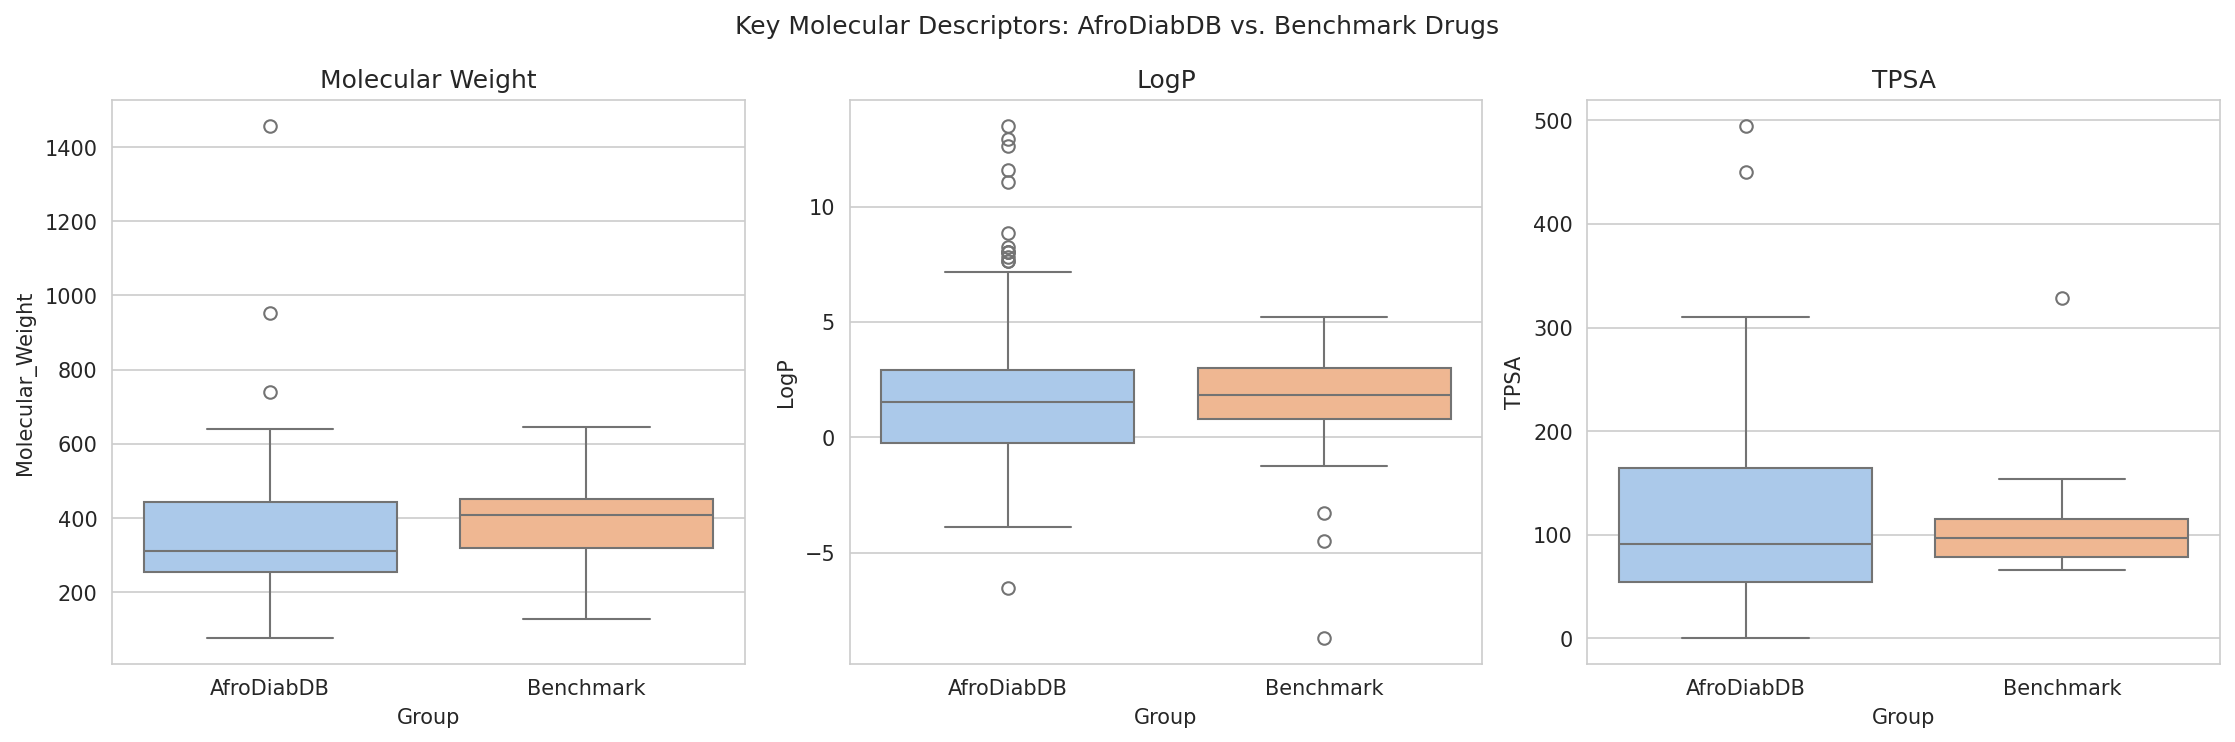

In [18]:
# Figure 3.3 — Boxplots
fig, axes = plt.subplots(1, 3, figsize=(15,5))
for i, desc in enumerate(['Molecular_Weight','LogP','TPSA']):
    combined = pd.concat([nat_unique[[desc]].assign(Group='AfroDiabDB'),
                           drugs_fixed[[desc]].assign(Group='Benchmark')])
    sns.boxplot(data=combined, x='Group', y=desc, ax=axes[i], palette='pastel')
    axes[i].set_title(desc.replace('_',' '))
plt.suptitle('Key Molecular Descriptors: AfroDiabDB vs. Benchmark Drugs')
plt.tight_layout()
plt.savefig(f'{output_dir}/figures/Figure_3_3_Descriptor_Boxplots.png', dpi=300)
plt.show()

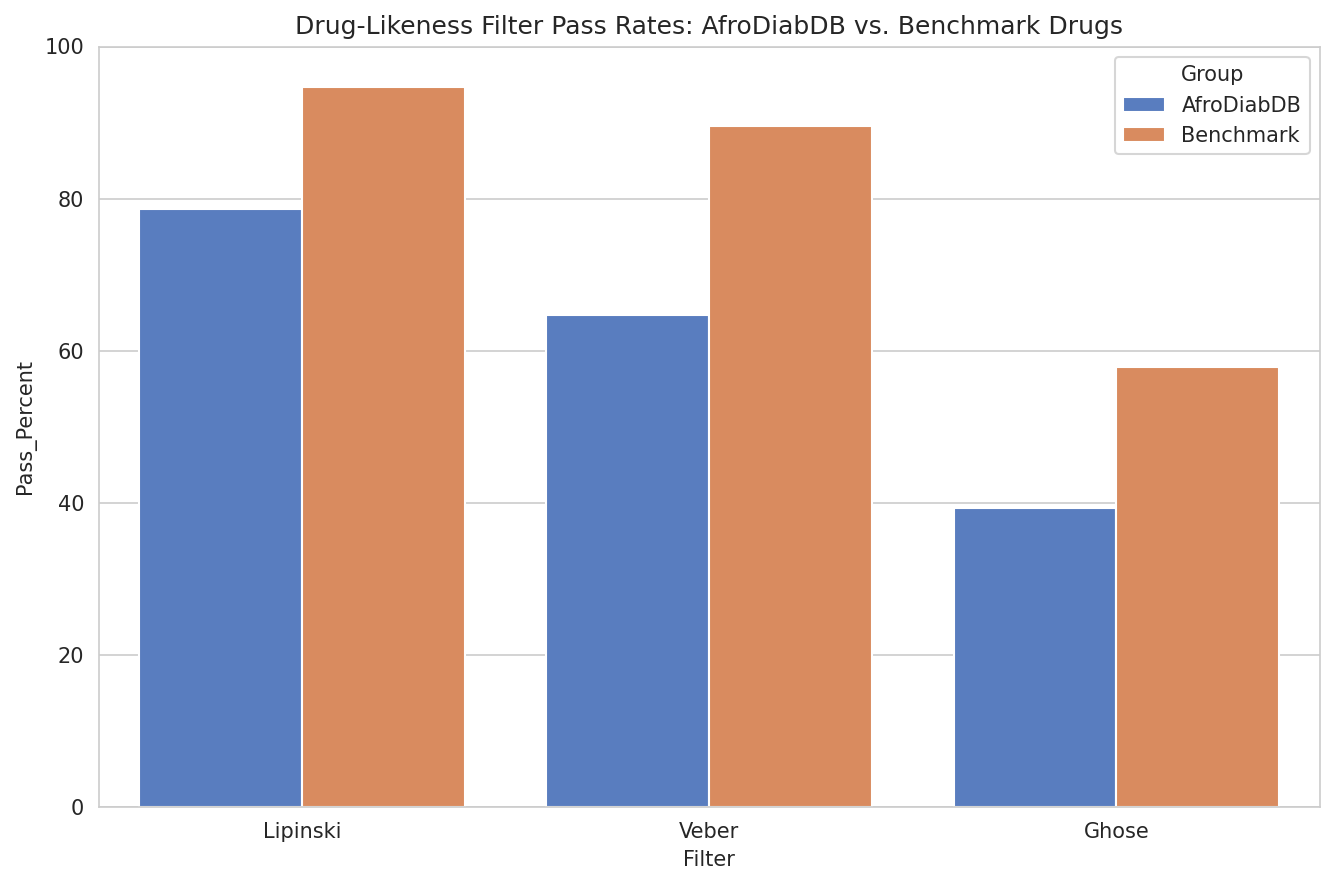

In [19]:
# Table 3.6 + Figure 3.4 — Drug-likeness pass rates
def pass_rate_summary(df, label):
    return pd.DataFrame({
        'Group':[label]*3, 'Filter':['Lipinski','Veber','Ghose'],
        'Pass':[(df['Lipinski_Status']=='Pass').sum(), (df['Veber_Status']=='Pass').sum(), (df['Ghose_Status']=='Pass').sum()],
        'Fail':[(df['Lipinski_Status']=='Fail').sum(), (df['Veber_Status']=='Fail').sum(), (df['Ghose_Status']=='Fail').sum()],
        'Total':[len(df)]*3
    })
table_3_6 = pd.concat([pass_rate_summary(nat_unique,'AfroDiabDB'), pass_rate_summary(drugs_fixed,'Benchmark')], ignore_index=True)
table_3_6['Pass_Percent'] = (table_3_6['Pass']/table_3_6['Total']*100).round(1)
table_3_6.to_csv(f'{output_dir}/tables/Table_3_6_Drug_Likeness_Rates.csv', index=False)

plt.figure(figsize=(9,6))
sns.barplot(data=table_3_6, x='Filter', y='Pass_Percent', hue='Group', palette='muted')
plt.title('Drug-Likeness Filter Pass Rates: AfroDiabDB vs. Benchmark Drugs')
plt.ylim(0,100)
plt.tight_layout()
plt.savefig(f'{output_dir}/figures/Figure_3_4_DrugLikeness_PassRates.png', dpi=300)
plt.show()

/tmp/ipykernel_452/1598836852.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nat_unique['QED_Category'] = nat_unique['QED_Score'].apply(qed_category)


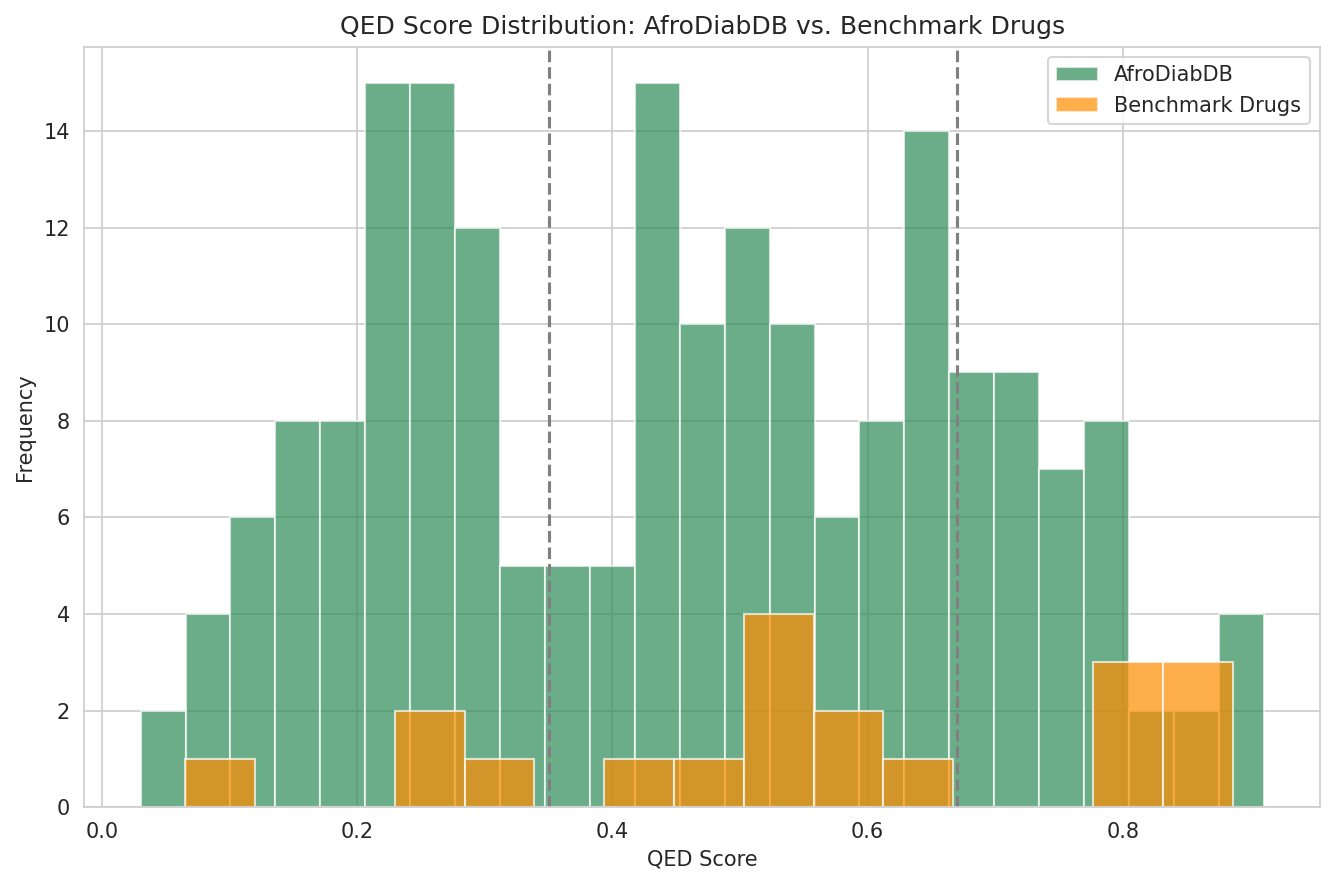

In [20]:
# Table 3.7 + Figure 3.5 — QED categories
def qed_category(q):
    if q < 0.35: return 'Low'
    elif q < 0.67: return 'Moderate'
    else: return 'High'

nat_unique['QED_Category'] = nat_unique['QED_Score'].apply(qed_category)
drugs_fixed['QED_Category'] = drugs_fixed['QED_Score'].apply(qed_category)

qed_nat = nat_unique['QED_Category'].value_counts().reindex(['Low','Moderate','High']).reset_index()
qed_nat.columns = ['QED_Category','AfroDiabDB_Count']
qed_drugs = drugs_fixed['QED_Category'].value_counts().reindex(['Low','Moderate','High']).reset_index()
qed_drugs.columns = ['QED_Category','Benchmark_Count']
table_3_7 = qed_nat.merge(qed_drugs, on='QED_Category')
table_3_7.to_csv(f'{output_dir}/tables/Table_3_7_QED_Categories.csv', index=False)

plt.figure(figsize=(9,6))
plt.hist(nat_unique['QED_Score'], bins=25, alpha=0.7, label='AfroDiabDB', color='seagreen')
plt.hist(drugs_fixed['QED_Score'], bins=15, alpha=0.7, label='Benchmark Drugs', color='darkorange')
plt.axvline(0.35, color='gray', linestyle='--'); plt.axvline(0.67, color='gray', linestyle='--')
plt.xlabel('QED Score'); plt.ylabel('Frequency')
plt.title('QED Score Distribution: AfroDiabDB vs. Benchmark Drugs')
plt.legend(); plt.tight_layout()
plt.savefig(f'{output_dir}/figures/Figure_3_5_QED_Histogram.png', dpi=300)
plt.show()

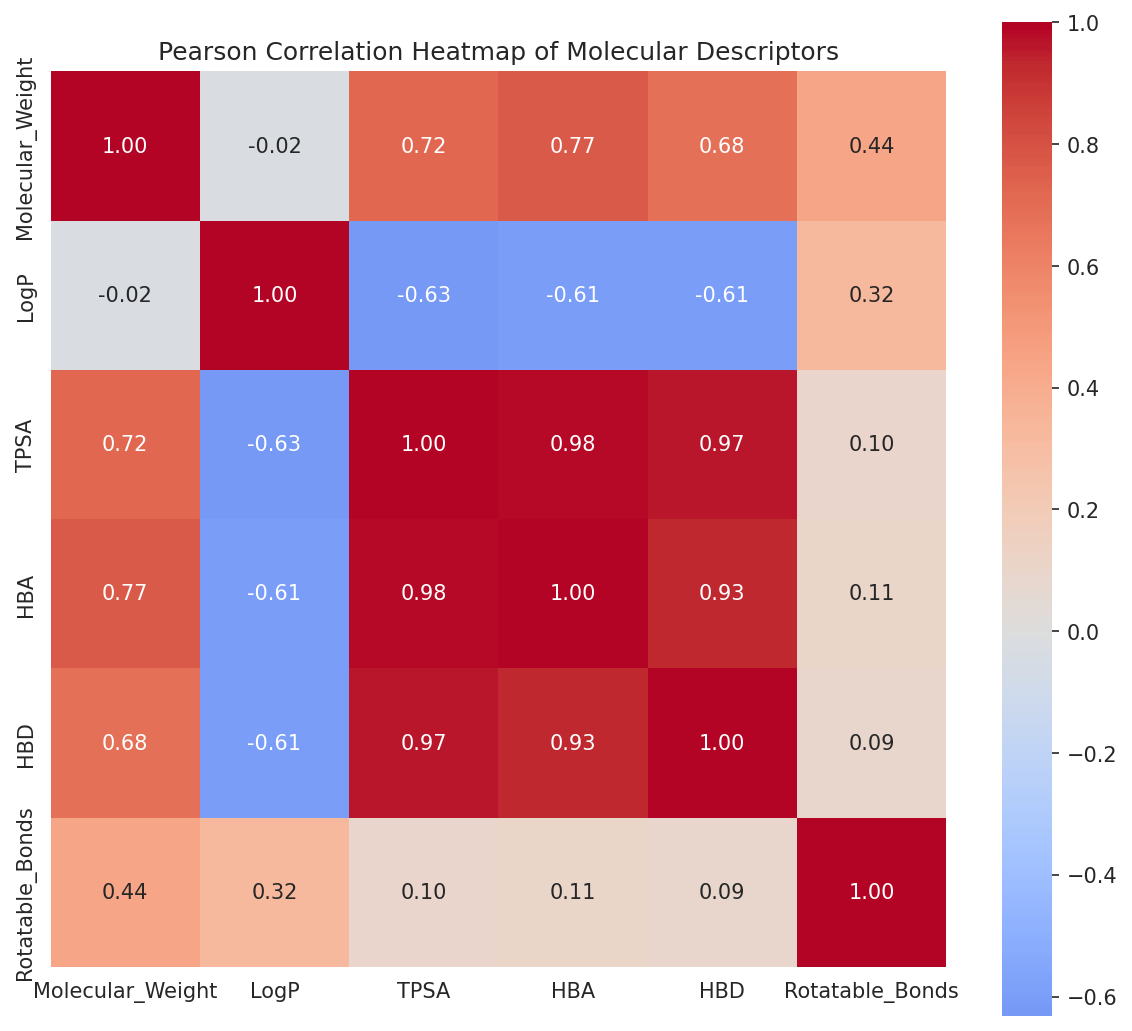

In [21]:
# Figure 3.6 + Table 3.9 — Correlation heatmap
corr_descriptors = ['Molecular_Weight','LogP','TPSA','HBA','HBD','Rotatable_Bonds']
corr_matrix = nat_unique[corr_descriptors].corr(method='pearson').round(3)
corr_matrix.to_csv(f'{output_dir}/tables/Table_3_9_Correlation_Matrix.csv')

plt.figure(figsize=(8,7))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True)
plt.title('Pearson Correlation Heatmap of Molecular Descriptors')
plt.tight_layout()
plt.savefig(f'{output_dir}/figures/Figure_3_6_Correlation_Heatmap.png', dpi=300)
plt.show()

In [22]:
# PCA setup + Table 3.8a/3.8b + Figures 3.7-3.9
pca_descriptors = ['Molecular_Weight','LogP','TPSA','HBA','HBD','Rotatable_Bonds']
nat_pca = nat_unique[pca_descriptors].copy(); nat_pca['Group']='AfroDiabDB'
drugs_pca = drugs_fixed[pca_descriptors].copy(); drugs_pca['Group']='Benchmark'
combined_pca = pd.concat([nat_pca, drugs_pca], ignore_index=True)

scaled = StandardScaler().fit_transform(combined_pca[pca_descriptors])
pca = PCA()
result = pca.fit_transform(scaled)
combined_pca['PC1'] = result[:,0]; combined_pca['PC2'] = result[:,1]

var_explained = pd.DataFrame({
    'Component':[f'PC{i+1}' for i in range(len(pca.explained_variance_ratio_))],
    'Variance_Explained_%': (pca.explained_variance_ratio_*100).round(2),
    'Cumulative_%': (np.cumsum(pca.explained_variance_ratio_)*100).round(2)
})
var_explained.to_csv(f'{output_dir}/tables/Table_3_8a_PCA_Variance.csv', index=False)

loadings = pd.DataFrame(pca.components_[:2].T, columns=['PC1_Loading','PC2_Loading'], index=pca_descriptors).round(3)
loadings.to_csv(f'{output_dir}/tables/Table_3_8b_PCA_Loadings.csv')
print(var_explained); print(); print(loadings)

  Component  Variance_Explained_%  Cumulative_%
0       PC1                 64.55         64.55
1       PC2                 24.85         89.40
2       PC3                  7.76         97.16
3       PC4                  2.00         99.16
4       PC5                  0.64         99.80
5       PC6                  0.20        100.00

                  PC1_Loading  PC2_Loading
Molecular_Weight        0.385        0.449
LogP                   -0.317        0.545
TPSA                    0.504       -0.049
HBA                     0.501       -0.018
HBD                     0.488       -0.066
Rotatable_Bonds         0.093        0.703


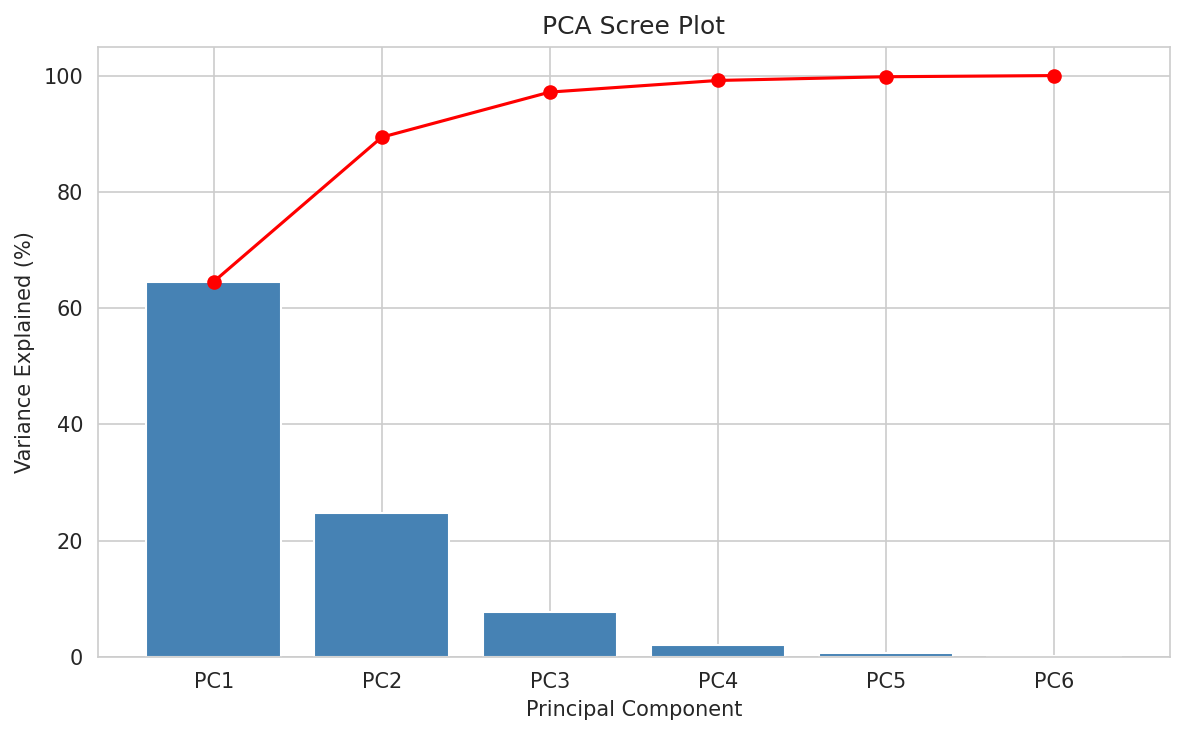

In [23]:
# Figure 3.7 — Scree plot
plt.figure(figsize=(8,5))
plt.bar(var_explained['Component'], var_explained['Variance_Explained_%'], color='steelblue')
plt.plot(var_explained['Component'], var_explained['Cumulative_%'], color='red', marker='o')
plt.xlabel('Principal Component'); plt.ylabel('Variance Explained (%)')
plt.title('PCA Scree Plot')
plt.tight_layout()
plt.savefig(f'{output_dir}/figures/Figure_3_7_Scree_Plot.png', dpi=300)
plt.show()

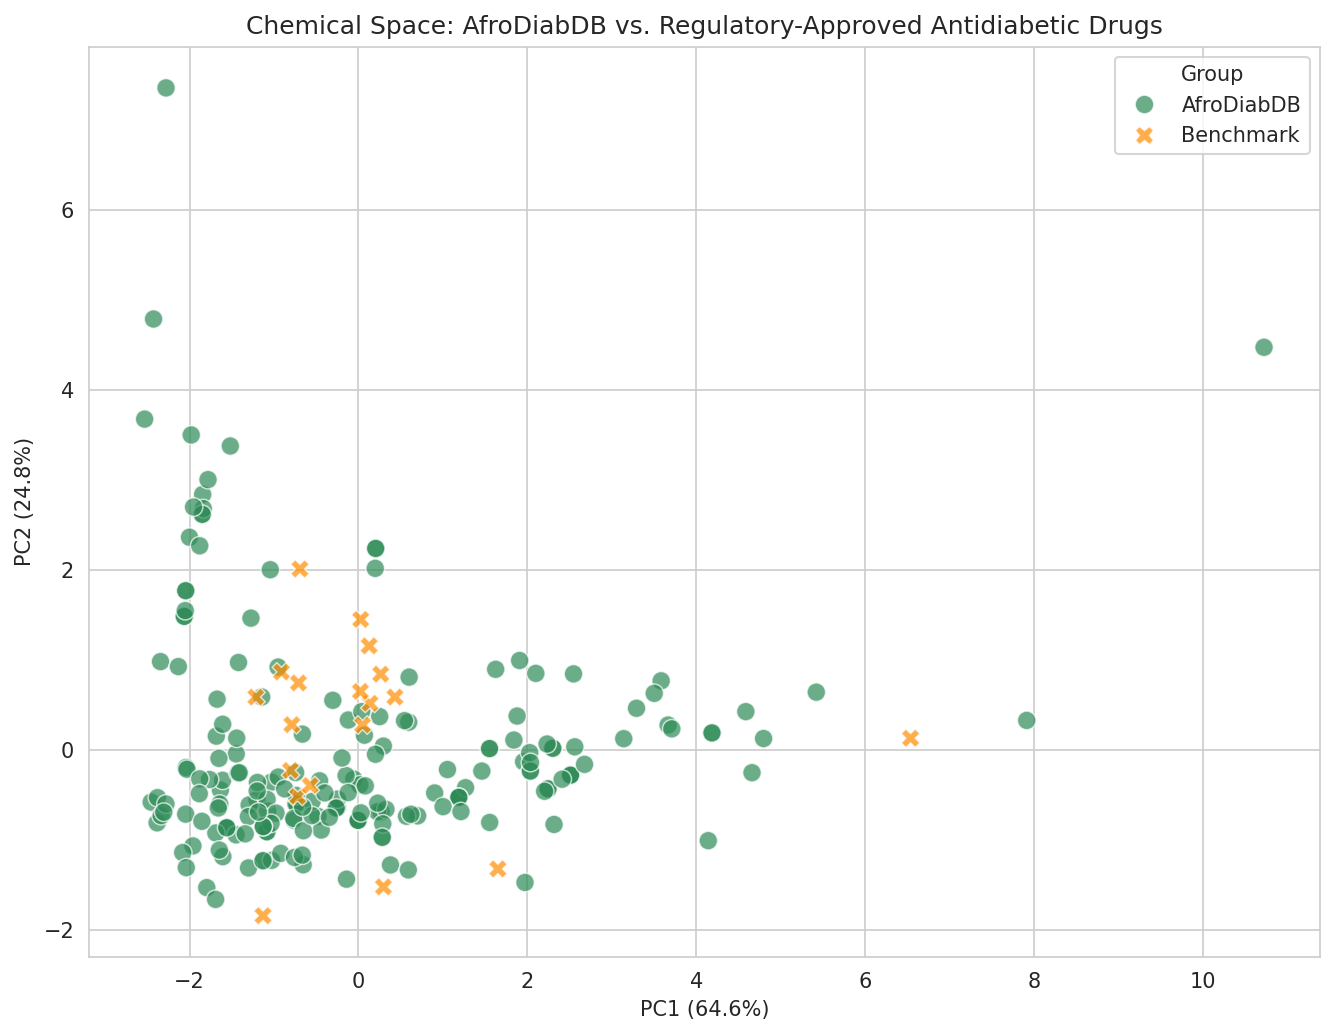

In [24]:
# Figure 3.8 — PCA score plot
plt.figure(figsize=(9,7))
sns.scatterplot(data=combined_pca, x='PC1', y='PC2', hue='Group', style='Group', s=80, alpha=0.7,
                 palette={'AfroDiabDB':'seagreen','Benchmark':'darkorange'})
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.title('Chemical Space: AfroDiabDB vs. Regulatory-Approved Antidiabetic Drugs')
plt.tight_layout()
plt.savefig(f'{output_dir}/figures/Figure_3_8_PCA_Score_Plot.png', dpi=300)
plt.show()

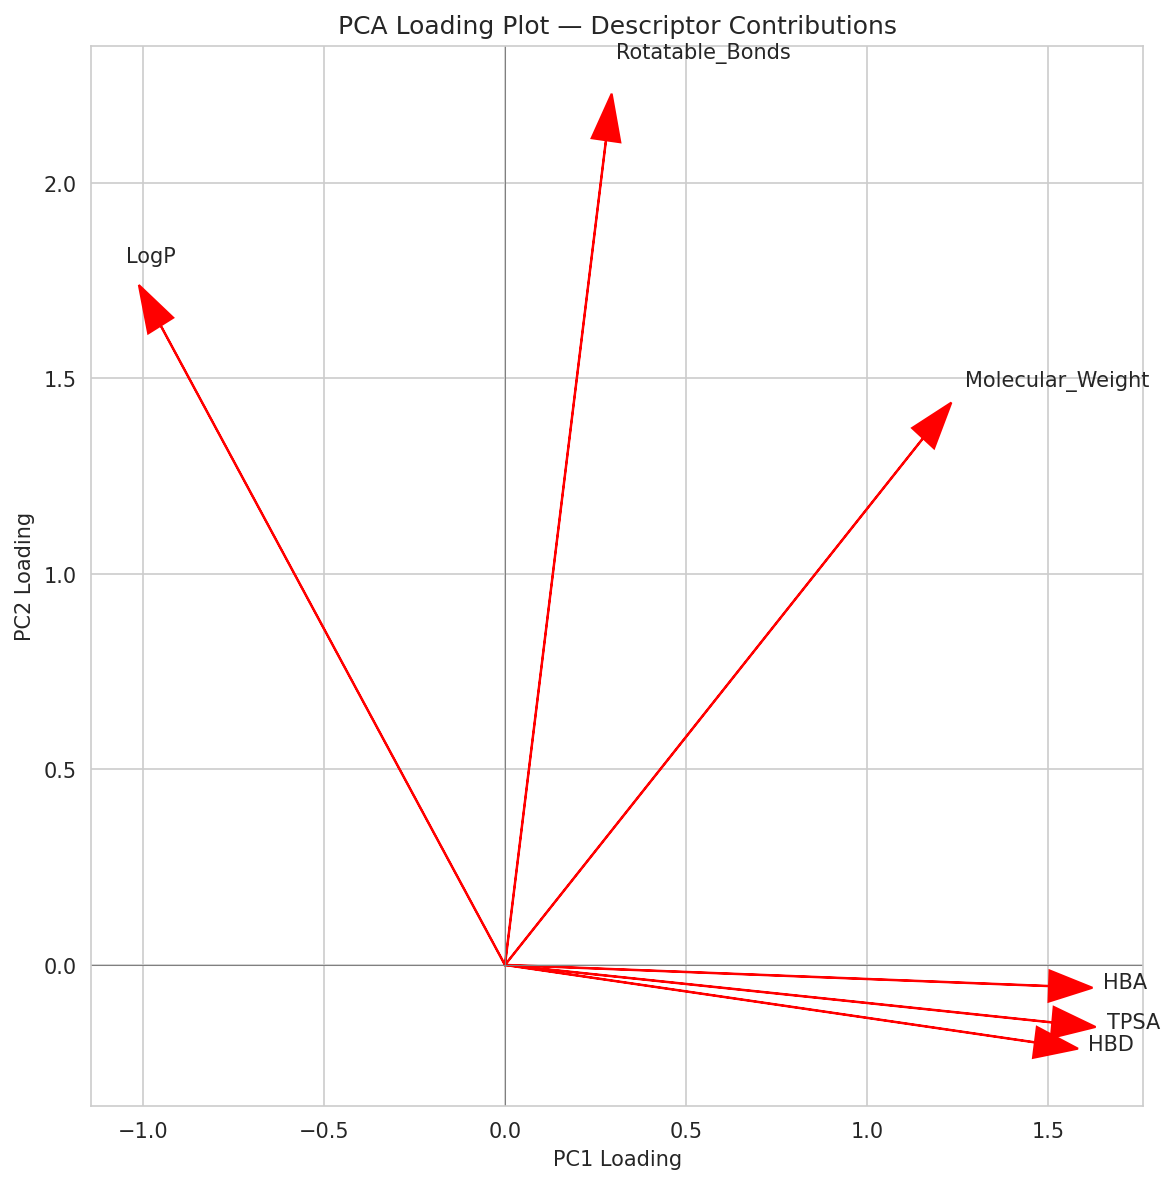

In [25]:
# Figure 3.9 — PCA loading biplot
plt.figure(figsize=(8,8))
for i, desc in enumerate(pca_descriptors):
    plt.arrow(0, 0, loadings.iloc[i,0]*3, loadings.iloc[i,1]*3, color='red', head_width=0.08)
    plt.text(loadings.iloc[i,0]*3.3, loadings.iloc[i,1]*3.3, desc, fontsize=10)
plt.axhline(0, color='gray', linewidth=0.5); plt.axvline(0, color='gray', linewidth=0.5)
plt.xlabel('PC1 Loading'); plt.ylabel('PC2 Loading')
plt.title('PCA Loading Plot — Descriptor Contributions')
plt.tight_layout()
plt.savefig(f'{output_dir}/figures/Figure_3_9_PCA_Loadings_Biplot.png', dpi=300)
plt.show()

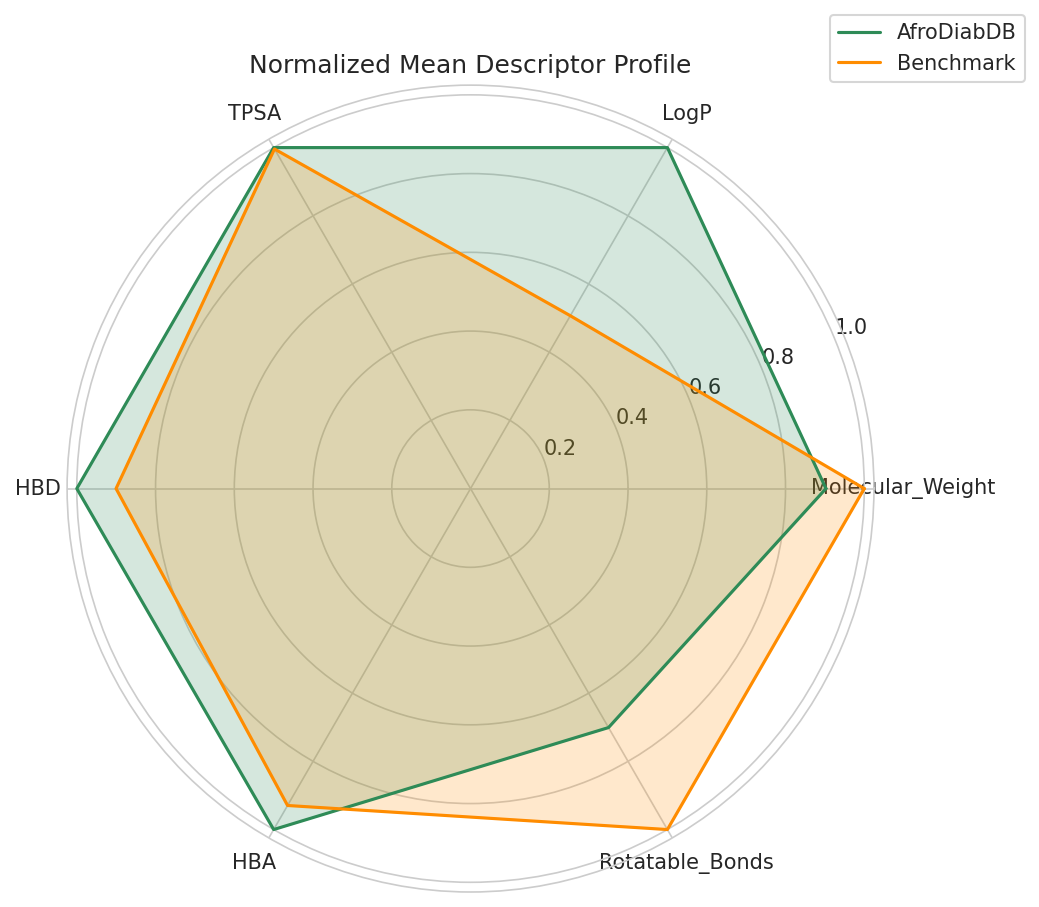

In [26]:
# Figure 3.10 — Radar plot
from math import pi
radar_descriptors = ['Molecular_Weight','LogP','TPSA','HBD','HBA','Rotatable_Bonds']
nat_means = nat_unique[radar_descriptors].mean()
drugs_means = drugs_fixed[radar_descriptors].mean()
norm_max = pd.concat([nat_means, drugs_means], axis=1).max(axis=1)
nat_norm = (nat_means/norm_max).tolist(); drugs_norm = (drugs_means/norm_max).tolist()
angles = [n/len(radar_descriptors)*2*pi for n in range(len(radar_descriptors))]
nat_norm += nat_norm[:1]; drugs_norm += drugs_norm[:1]; angles += angles[:1]

fig, ax = plt.subplots(figsize=(7,7), subplot_kw=dict(polar=True))
ax.plot(angles, nat_norm, label='AfroDiabDB', color='seagreen'); ax.fill(angles, nat_norm, color='seagreen', alpha=0.2)
ax.plot(angles, drugs_norm, label='Benchmark', color='darkorange'); ax.fill(angles, drugs_norm, color='darkorange', alpha=0.2)
ax.set_xticks(angles[:-1]); ax.set_xticklabels(radar_descriptors)
plt.title('Normalized Mean Descriptor Profile')
plt.legend(loc='upper right', bbox_to_anchor=(1.2,1.1))
plt.tight_layout()
plt.savefig(f'{output_dir}/figures/Figure_3_10_Radar_Plot.png', dpi=300)
plt.show()

/tmp/ipykernel_452/3108255084.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_counts.values, y=country_counts.index, palette='crest')


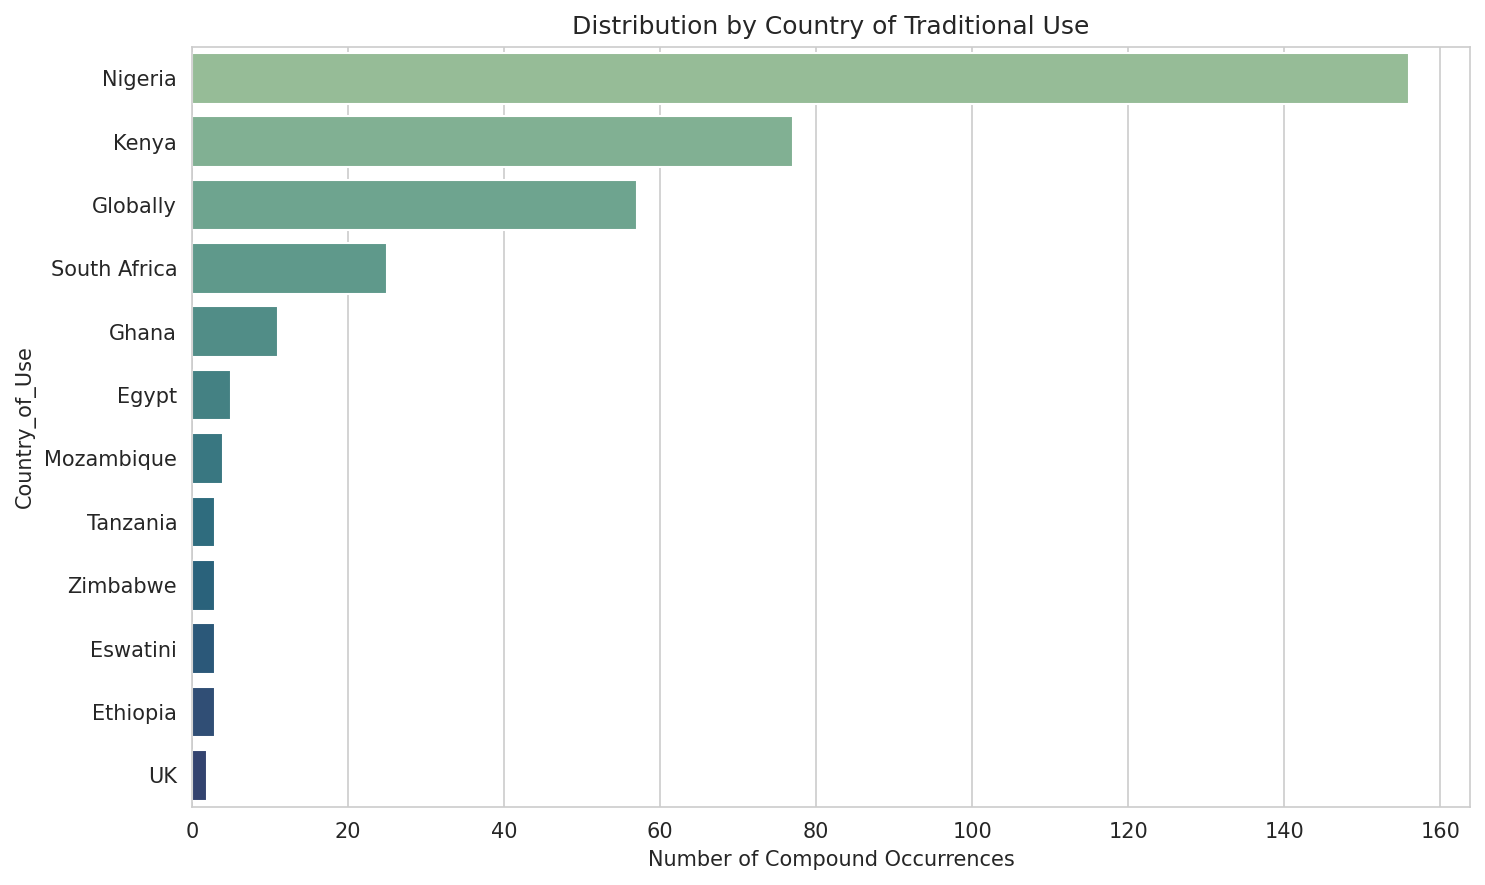

In [27]:
# Figure 3.11 — Country of use distribution
country_series = nat_final['Country_of_Use'].str.split(';').explode().str.strip()
country_counts = country_series.value_counts().head(12)

plt.figure(figsize=(10,6))
sns.barplot(x=country_counts.values, y=country_counts.index, palette='crest')
plt.xlabel('Number of Compound Occurrences')
plt.title('Distribution by Country of Traditional Use')
plt.tight_layout()
plt.savefig(f'{output_dir}/figures/Figure_3_11_Country_Distribution.png', dpi=300)
plt.show()

In [29]:
# Confirm everything saved
print("Figures:")
for f in sorted(os.listdir(f'{output_dir}/figures')): print(" ", f)
print("\nTables:")
for f in sorted(os.listdir(f'{output_dir}/tables')): print(" ", f)

Figures:
  Figure_3_10_Radar_Plot.png
  Figure_3_11_Country_Distribution.png
  Figure_3_1_Top_Plant_Families.png
  Figure_3_1b_Plant_Part_Distribution.png
  Figure_3_2_Superclass_Distribution.png
  Figure_3_3_Descriptor_Boxplots.png
  Figure_3_4_DrugLikeness_PassRates.png
  Figure_3_5_QED_Histogram.png
  Figure_3_6_Correlation_Heatmap.png
  Figure_3_7_Scree_Plot.png
  Figure_3_8_PCA_Score_Plot.png
  Figure_3_9_PCA_Loadings_Biplot.png

Tables:
  Table_3_1_Database_Summary.csv
  Table_3_2_Top_Plant_Families.csv
  Table_3_2b_Plant_Part_Distribution.csv
  Table_3_3_Superclass_Distribution.csv
  Table_3_4_AfroDiabDB_Descriptors.csv
  Table_3_5_Benchmark_Descriptors.csv
  Table_3_6_Drug_Likeness_Rates.csv
  Table_3_7_QED_Categories.csv
  Table_3_8a_PCA_Variance.csv
  Table_3_8b_PCA_Loadings.csv
  Table_3_9_Correlation_Matrix.csv


In [30]:

from google.colab import userdata
import os, shutil

github_token = userdata.get('GITHUB_TOKEN')
github_username = 'Lydia-fadele'
repo_name = 'AfroDiabDB'
repo_url = f'https://{github_token}@github.com/{github_username}/{repo_name}.git'

if not os.path.exists(f'/content/{repo_name}'):
    !git clone {repo_url} /content/{repo_name}
else:
    !cd /content/{repo_name} && git pull

# Wipe old figures/tables so nothing stale is left behind, then recreate clean folders
for folder in ['data', 'figures', 'tables', 'notebooks']:
    repo_folder = f'/content/{repo_name}/{folder}'
    if os.path.exists(repo_folder):
        shutil.rmtree(repo_folder)
    os.makedirs(repo_folder, exist_ok=True)

# Copy in the fresh files generated this session
!cp {out_name} /content/{repo_name}/data/AfroDiabDB_v1.4.xlsx
!cp {export_dir}/*.csv /content/{repo_name}/data/
!cp {export_dir}/*.sdf /content/{repo_name}/data/
!cp {output_dir}/figures/*.png /content/{repo_name}/figures/
!cp {output_dir}/tables/*.csv /content/{repo_name}/tables/

!cd /content/{repo_name} && git add .
!cd /content/{repo_name} && git config user.email "diamondlydia19@gmail.com"
!cd /content/{repo_name} && git config user.name "Lydia Fadele"
!cd /content/{repo_name} && git commit -m "Update AfroDiabDB: replace data, figures, and tables"
!cd /content/{repo_name} && git push

print("Pushed to GitHub successfully.")

Cloning into '/content/AfroDiabDB'...
remote: Enumerating objects: 134, done.
remote: Counting objects: 100% (134/134), done.
remote: Compressing objects: 100% (123/123), done.
remote: Total 134 (delta 43), reused 61 (delta 7), pack-reused 0 (from 0)
Receiving objects: 100% (134/134), 8.11 MiB | 6.94 MiB/s, done.
Resolving deltas: 100% (43/43), done.
[main d88941a] Update AfroDiabDB: replace data, figures, and tables
 59 files changed, 24548 insertions(+), 26829 deletions(-)
 create mode 100644 data/AfroDiabDB_Clinically_Approved_Drugs.csv
 create mode 100644 data/AfroDiabDB_Clinically_Approved_Drugs.sdf
 create mode 100644 data/AfroDiabDB_Natural_Products.csv
 create mode 100644 data/AfroDiabDB_Natural_Products.sdf
 delete mode 100644 data/AfroDiabDB_v1.0.xlsx
 delete mode 100644 data/AfroDiabDB_v1.1_Full_Master_Curated.csv
 delete mode 100644 data/AfroDiabDB_v1.1_Full_Master_Curated.xlsx
 delete mode 100644 data/AfroDiabDB_v1.1_Unique_Library_Curated.xlsx
 delete mode 100644 data/Afr